In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math

In [2]:
#il nostro integrale ha una sorta di gaussiana. Sapendo quanti fa l'integrale gaussiano posso rinormalizzarla (vedi appunti)

sigma = 1 #decido il valore da dare a sigma nel risultato dell'integrale
xi=np.abs(np.random.normal(0, sigma, 100000)) #p(x): genera sample gaussiano e voglio solo valori positivi (per integrare tra 0 e infinito)

integral = ((np.sqrt(2*np.pi*sigma**2))/2) * np.mean((xi**3)) #integro la mia f(x) motliplicata per la normalizzazione

integral

1.981881918111457

In [20]:
#studio dei resdui all'aumentare del numero di sample (convergenza al valore vero)
true_v = 2*(sigma**4)
N = np.linspace(100, 1000000, 10000, dtype=int) #genero sample di N tra 100 e 100000 con step 1000
result_n = []
truev_vec = []

for i in range(len(N)):
    xi_n = np.abs(np.random.normal(0,sigma,N[i]))
    result_n.append(((np.sqrt(2*np.pi*sigma**2))/2) * np.mean(xi_n**3))
    #error_n.append(true_v-((np.sqrt(2*np.pi*sigma**2))/2) * np.mean((xi_n**3)))
    truev_vec.append(true_v)
    
error_n = (np.array(result_n) - true_v)/true_v

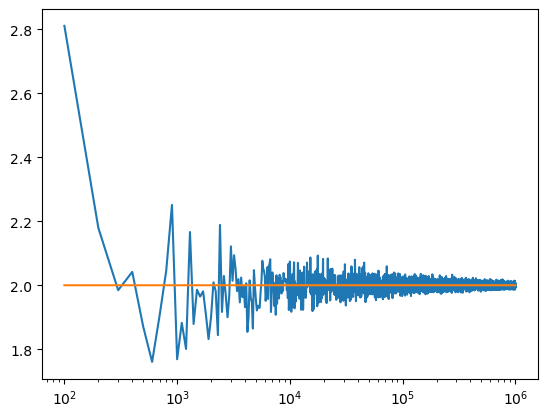

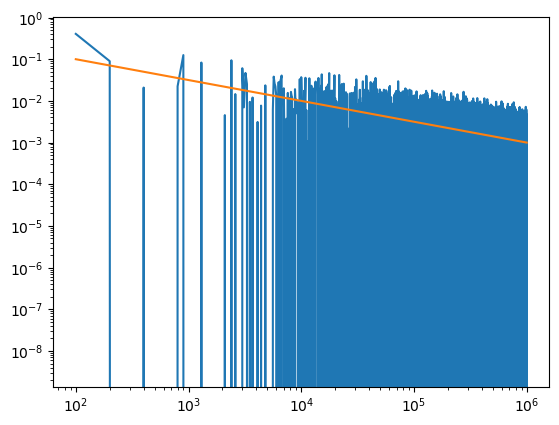

In [21]:
plt.plot(N,result_n)
plt.plot(N,truev_vec)
plt.xscale('log')
plt.show()

plt.plot(N, error_n)
plt.plot(N,N**(-0.5))
plt.loglog()
plt.show()

In [22]:
#andamento degli errori per N fissato
error_fixedN = []
N = 10000

for i in range(N):
    xi_fixedN = np.abs(np.random.normal(0,sigma,N))
    error_fixedN.append(true_v-((np.sqrt(2*np.pi*sigma**2))/2) * np.mean((xi_fixedN**3)))

In [23]:
def gauss_fit(x,mu,std): #definisco gaussiana analitica per fit
    return (1/np.sqrt(2 * np.pi * std**2)) * np.exp(- ((x-mu)**2) / (2 * std**2))

myfit = gauss_fit(np.linspace(np.min(error_fixedN),np.max(error_fixedN),N),np.mean(error_fixedN),np.std(error_fixedN))

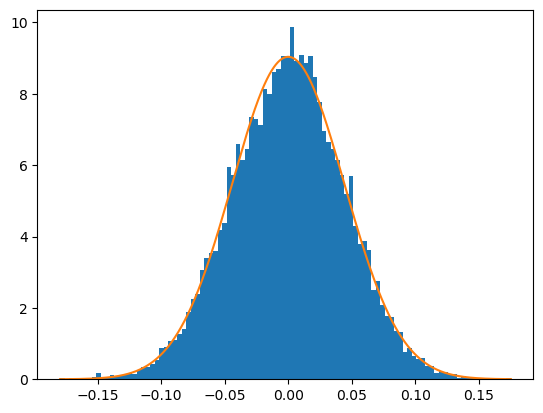

In [24]:
plt.hist(np.array(error_fixedN), bins=int(np.sqrt(N)), density=True)
plt.plot(np.linspace(np.min(error_fixedN),np.max(error_fixedN),N),myfit)
#se l'errore va come sqrt(N)  ha senso prendere bin ~ sqrt(N)
#density=True normalizza!!!